In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING THE DATASET

In [4]:
df = pd.read_csv("train_occupancy.csv", encoding= 'unicode_escape')

# DATASET OVERVIEW

In [5]:
df.head()

,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
0,9,Miranda,2017-01-10 00:18:17,2017-01-10 00:19:04,Down,620S,Illawarra,Central,Cronulla,T,18,00:15-00:29,MANY_SEATS_AVAILABLE,Low: 0-399
1,13,Beecroft,2017-01-13 08:05:59,2017-01-13 08:06:56,Down,152C,North via Macquarie Park,Central,Hornsby,A,16,08:00-08:14,MANY_SEATS_AVAILABLE,Low: 0-399
2,12,Arncliffe,2017-01-12 07:22:51,2017-01-12 07:23:36,Down,607B,Illawarra,Central,Waterfall,T,6,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
3,13,Dulwich Hill,2017-01-13 07:20:39,2017-01-13 07:21:53,Down,58-F,Bankstown,Central,Birrong,A,7,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
4,11,Belmore,2017-01-11 18:38:28,2017-01-11 18:39:07,Up,33-P,Bankstown,Birrong,Central,K,7,18:30-18:44,MANY_SEATS_AVAILABLE,Low: 0-399


In [6]:
df.tail()

,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
50245,11,Rockdale,2017-01-11 13:28:05,2017-01-11 13:28:50,Down,616H,Illawarra,Central,Waterfall,T,8,13:15-13:29,MANY_SEATS_AVAILABLE,Low: 0-399
50246,16,Redfern,2017-01-16 07:40:04,2017-01-16 07:40:49,Up,39-C,South,Leppington,Central,K,19,07:30-07:44,FEW_SEATS_AVAILABLE,High: 800+
50247,12,Town Hall,2017-01-12 18:52:23,2017-01-12 18:54:02,Up,107J,North Shore,Hornsby,Central,T,19,18:45-18:59,MANY_SEATS_AVAILABLE,Medium: 400-799
50248,12,Blacktown,2017-01-12 08:12:00,2017-01-12 08:13:30,Up,159C,West,Blacktown,Central,A,1,08:00-08:14,MANY_SEATS_AVAILABLE,Low: 0-399
50249,16,Wynyard,2017-01-16 08:09:16,2017-01-16 08:10:03,Up,65-E,City Circle,Central,Central,A,3,08:00-08:14,MANY_SEATS_AVAILABLE,Medium: 400-799


In [7]:
df.shape

(50250, 14)

In [8]:
df.columns 

Index(['day', 'Actual.Stop.Station', 'Actual.Station.Arrv.Time',
       'Actual.Station.Dprt.Time', 'Segment.Direction', 'Trip.Name',
       'Service.Line', 'Orig..Station', 'Dest..Station', 'Leading.Set.Type',
       'Node.Seq.Order', 'Actual.Station.Dprt.Time.Band', 'Occupancy Status',
       'Occupancy Range'],
      dtype='object')

In [9]:
df.dtypes

day                               int64
Actual.Stop.Station              object
Actual.Station.Arrv.Time         object
Actual.Station.Dprt.Time         object
Segment.Direction                object
Trip.Name                        object
Service.Line                     object
Orig..Station                    object
Dest..Station                    object
Leading.Set.Type                 object
Node.Seq.Order                    int64
Actual.Station.Dprt.Time.Band    object
Occupancy Status                 object
Occupancy Range                  object
dtype: object

In [10]:
df.describe()

,day,Node.Seq.Order
count,50250.000000,50250.000000
mean,12.805075,8.888438
std,2.034840,6.047581
min,9.000000,1.000000
25%,11.000000,4.000000
50%,13.000000,8.000000
75%,15.000000,13.000000
max,16.000000,38.000000


In [11]:
unique_counts = df.nunique()
print(unique_counts)

day                                  8
Actual.Stop.Station                307
Actual.Station.Arrv.Time         47198
Actual.Station.Dprt.Time         43139
Segment.Direction                    4
Trip.Name                         3587
Service.Line                        30
Orig..Station                       67
Dest..Station                       68
Leading.Set.Type                    10
Node.Seq.Order                      38
Actual.Station.Dprt.Time.Band       96
Occupancy Status                     6
Occupancy Range                      3
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50250 entries, 0 to 50249
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   day                            50250 non-null  int64 
 1   Actual.Stop.Station            50176 non-null  object
 2   Actual.Station.Arrv.Time       50243 non-null  object
 3   Actual.Station.Dprt.Time       50239 non-null  object
 4   Segment.Direction              50172 non-null  object
 5   Trip.Name                      50250 non-null  object
 6   Service.Line                   50191 non-null  object
 7   Orig..Station                  50170 non-null  object
 8   Dest..Station                  50187 non-null  object
 9   Leading.Set.Type               50173 non-null  object
 10  Node.Seq.Order                 50250 non-null  int64 
 11  Actual.Station.Dprt.Time.Band  50250 non-null  object
 12  Occupancy Status               50177 non-null  object
 13  O

In [13]:
df.isnull().sum()

day                               0
Actual.Stop.Station              74
Actual.Station.Arrv.Time          7
Actual.Station.Dprt.Time         11
Segment.Direction                78
Trip.Name                         0
Service.Line                     59
Orig..Station                    80
Dest..Station                    63
Leading.Set.Type                 77
Node.Seq.Order                    0
Actual.Station.Dprt.Time.Band     0
Occupancy Status                 73
Occupancy Range                   0
dtype: int64

In [14]:
df.isnull().sum().sum()

np.int64(522)

In [15]:
df.duplicated().sum()

np.int64(250)

# DATASET CLEANING 

In [16]:
df.duplicated().sum()

np.int64(250)

In [17]:
df[df.duplicated()].head()

,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
275,15,Wolli Creek,2017-01-15 21:53:56,2017-01-15 21:54:56,Up,75-S,Airport,Revesby,Central,A,10,21:45-21:59,MANY_SEATS_AVAILABLE,Low: 0-399
1516,11,Niagara Park,2017-01-11 12:52:03,2017-01-11 12:52:03,Up,299E,North,Hamilton,Central,H,19,12:45-12:59,MANY_SEATS_AVAILABLE,Low: 0-399
2018,12,Olympic Park,2017-01-12 16:34:55,2017-01-12 16:37:25,Up,L1CV,Olympic Park West/South,Lidcombe,Olympic Park,S,2,16:30-16:44,MANY_SEATS_AVAILABLE,Low: 0-399
2615,11,Niagara Park,2017-01-11 18:53:19,2017-01-11 18:53:19,Down,284P,North,Gosford,Hamilton,H,3,18:45-18:59,MANY_SEATS_AVAILABLE,Low: 0-399
2811,10,Niagara Park,2017-01-10 06:53:27,2017-01-10 06:53:27,Up,211C,North,Hamilton,Gosford,H,19,06:45-06:59,MANY_SEATS_AVAILABLE,Low: 0-399


In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isnull().sum()

day                               0
Actual.Stop.Station              72
Actual.Station.Arrv.Time          7
Actual.Station.Dprt.Time         11
Segment.Direction                78
Trip.Name                         0
Service.Line                     59
Orig..Station                    79
Dest..Station                    63
Leading.Set.Type                 76
Node.Seq.Order                    0
Actual.Station.Dprt.Time.Band     0
Occupancy Status                 73
Occupancy Range                   0
dtype: int64

In [21]:
df = df.rename(columns={'Actual.Stop.Station': 'stop_station',
    'Actual.Station.Arrv.Time': 'arrival_time',
    'Actual.Station.Dprt.Time': 'departure_time',
    'Segment.Direction': 'direction',
    'Trip.Name': 'trip_name',
    'Service.Line': 'service_line',
    'Orig..Station': 'origin_station',
    'Dest..Station': 'destination_station',
    'Leading.Set.Type': 'train_type',
    'Node.Seq.Order': 'node_seq_order',
    'Actual.Station.Dprt.Time.Band': 'departure_time_band',
    'Occupancy Status': 'occupancy_status',
    'Occupancy Range': 'occupancy_range'
})

In [22]:
df.columns 

Index(['day', 'stop_station', 'arrival_time', 'departure_time', 'direction',
       'trip_name', 'service_line', 'origin_station', 'destination_station',
       'train_type', 'node_seq_order', 'departure_time_band',
       'occupancy_status', 'occupancy_range'],
      dtype='object')

In [23]:
df['arrival_time'] = pd.to_datetime(df['arrival_time'], errors='coerce')
df['departure_time'] = pd.to_datetime(df['departure_time'], errors='coerce')

In [24]:
df.head()

,day,stop_station,arrival_time,departure_time,direction,trip_name,service_line,origin_station,destination_station,train_type,node_seq_order,departure_time_band,occupancy_status,occupancy_range
0,9,Miranda,2017-01-10 00:18:17,2017-01-10 00:19:04,Down,620S,Illawarra,Central,Cronulla,T,18,00:15-00:29,MANY_SEATS_AVAILABLE,Low: 0-399
1,13,Beecroft,2017-01-13 08:05:59,2017-01-13 08:06:56,Down,152C,North via Macquarie Park,Central,Hornsby,A,16,08:00-08:14,MANY_SEATS_AVAILABLE,Low: 0-399
2,12,Arncliffe,2017-01-12 07:22:51,2017-01-12 07:23:36,Down,607B,Illawarra,Central,Waterfall,T,6,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
3,13,Dulwich Hill,2017-01-13 07:20:39,2017-01-13 07:21:53,Down,58-F,Bankstown,Central,Birrong,A,7,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
4,11,Belmore,2017-01-11 18:38:28,2017-01-11 18:39:07,Up,33-P,Bankstown,Birrong,Central,K,7,18:30-18:44,MANY_SEATS_AVAILABLE,Low: 0-399


# Creating New Columns 

In [25]:
df['departure_hour'] = df['departure_time'].dt.hour

In [26]:
df['peak_period'] = df['departure_hour'].apply(lambda x: 'Peak' if x in [7,8,9,16,17,18] else 'Non-Peak')


In [27]:
df['stop_time'] = (df['departure_time'] - df['arrival_time']).dt.total_seconds() / 60

In [28]:
df.columns 

Index(['day', 'stop_station', 'arrival_time', 'departure_time', 'direction',
       'trip_name', 'service_line', 'origin_station', 'destination_station',
       'train_type', 'node_seq_order', 'departure_time_band',
       'occupancy_status', 'occupancy_range', 'departure_hour', 'peak_period',
       'stop_time'],
      dtype='object')

## Check for invalid values 

In [29]:
df['direction'].value_counts()

direction
Up       25072
Down     24694
Up          79
Down        77
Name: count, dtype: int64

In [30]:
df['direction'] = df['direction'].str.strip()

In [31]:
df['direction'].value_counts()

direction
Up      25151
Down    24771
Name: count, dtype: int64

In [32]:
df['service_line'].value_counts()

service_line
Illawarra                    7551
West                         6233
North Shore                  4794
Airport                      4563
Bankstown                    4134
South                        3628
City Circle                  3178
North  via Macquarie Park    3097
North                        2761
Eastern Suburbs              2267
Inner West                   2196
North  via  Strathfield      1711
Hunter Valley                1082
Cumberland                   1049
Olympic Park West/South       524
Carlingford Shuttle           297
Illawarra to Sydney           191
North Coast                   158
East Hills                    152
South Coast                   142
Port Kembla                   136
NORTH SHORE                    18
AIRPORT                        17
city circle                    17
EASTERN SUBURBS                12
Cenoral Coast                  10
Hunter Valley                   7
Central Coast                   7
north coast                     6
s

In [33]:
df['service_line'] = df['service_line'].str.strip()
df['service_line'] = df['service_line'].str.replace(r'\s+', ' ', regex=True)
df['service_line'] = df['service_line'].str.title()
df['service_line'] = df['service_line'].replace({
    "Cenoral Coast": "Central Coast",
    "Illawarra To Sydney": "Illawarra"})

In [34]:
df['service_line'].value_counts()

service_line
Illawarra                   7742
West                        6233
North Shore                 4812
Airport                     4580
Bankstown                   4134
South                       3628
City Circle                 3195
North Via Macquarie Park    3097
North                       2761
Eastern Suburbs             2279
Inner West                  2196
North Via Strathfield       1711
Hunter Valley               1089
Cumberland                  1049
Olympic Park West/South      524
Carlingford Shuttle          297
North Coast                  164
East Hills                   152
South Coast                  145
Port Kembla                  136
Central Coast                 17
Name: count, dtype: int64

In [35]:
df['train_type'].value_counts()

train_type
A    22804
T     9854
H     4778
M     4026
K     2664
V     2423
S     1083
C      962
J      913
N      417
Name: count, dtype: int64

In [36]:
df['occupancy_status'].value_counts()

occupancy_status
MANY_SEATS_AVAILABLE    47771
FEW_SEATS_AVAILABLE      1587
STANDING_ROOM_ONLY        397
MANY_SEATSAVAILABLE       162
few_seats_available         8
VTANDING_ROOM_ONLY          2
Name: count, dtype: int64

In [37]:
df['occupancy_status'] = df['occupancy_status'].str.upper().str.strip()
df['occupancy_status'] = df['occupancy_status'].replace({
    "MANY_SEATSAVAILABLE": "MANY_SEATS_AVAILABLE",
    "VTANDING_ROOM_ONLY": "STANDING_ROOM_ONLY"})

In [38]:
df['occupancy_status'].value_counts()

occupancy_status
MANY_SEATS_AVAILABLE    47933
FEW_SEATS_AVAILABLE      1595
STANDING_ROOM_ONLY        399
Name: count, dtype: int64

In [39]:
df['occupancy_range'].value_counts()

occupancy_range
Low: 0-399         45699
Medium: 400-799     3542
High: 800+           759
Name: count, dtype: int64

# EDA on Numerical Features 

## Numerical Feature 1: departure_hour

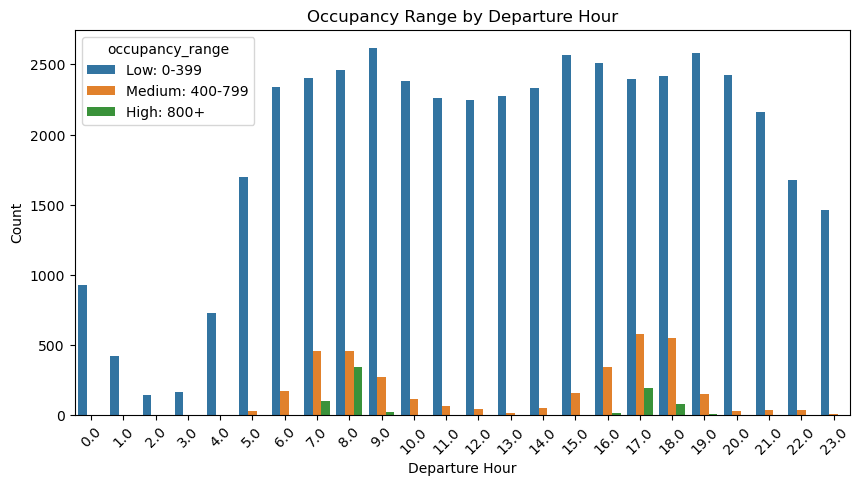

In [40]:
plt.figure(figsize=(10,5))
sns.countplot(x='departure_hour', hue='occupancy_range', data=df)
plt.title("Occupancy Range by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Insights: Higher occupancy during morning and evening peak hours & Lower occupancy late at night or mid-day

## Numerical Feature 2: stop_time

In [55]:
df['stop_time_category'] = pd.cut(df['stop_time'], bins=[-1, 1, 3, 10], 
                                  labels=['Short (0-1 min)', 'Medium (1-3 min)', 'Long (3+ min)'])

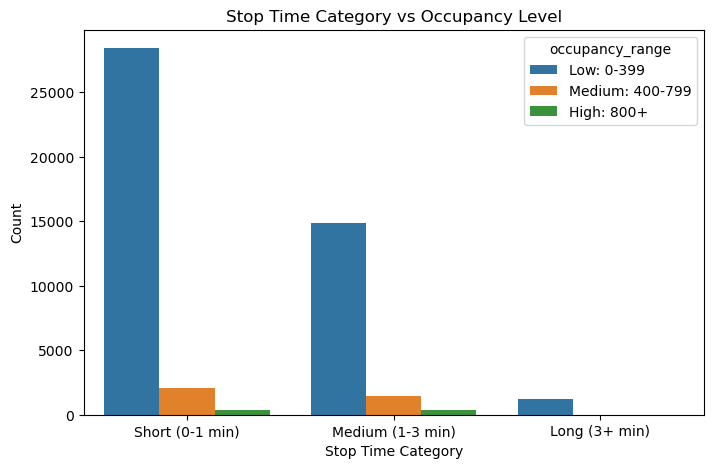

In [49]:
plt.figure(figsize=(8,5))
sns.countplot(x='stop_time_category', hue='occupancy_range', data=df)
plt.title("Stop Time Category vs Occupancy Level")
plt.xlabel("Stop Time Category")
plt.ylabel("Count")
plt.show()

Insight: Across all stop time categories the vast majority of instances fall into the "Low: 0-399" occupancy range. The "Short (0-1 min)" category has the highest overall count by a wide margin, making it the most frequent type of stop.

## Correlation between Numerical Variables

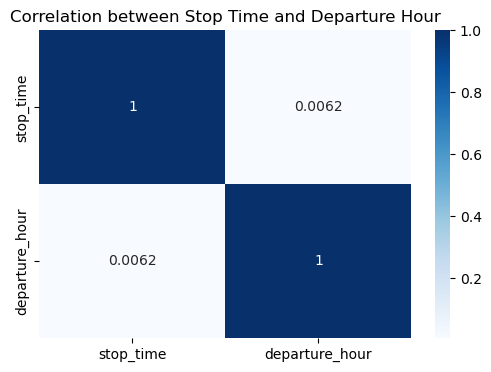

In [56]:
numeric_df = df[['stop_time', 'departure_hour']]
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title("Correlation between Stop Time and Departure Hour")
plt.show()

The correlation between stop time and departure hour is very low, which means stop time does not depend much on the time of day.

Insight: The values are very close to 0, which means there is no strong relationship between Numerical Variables.

# EDA on Categorical Features 

## Categorical Feature 1: service_line

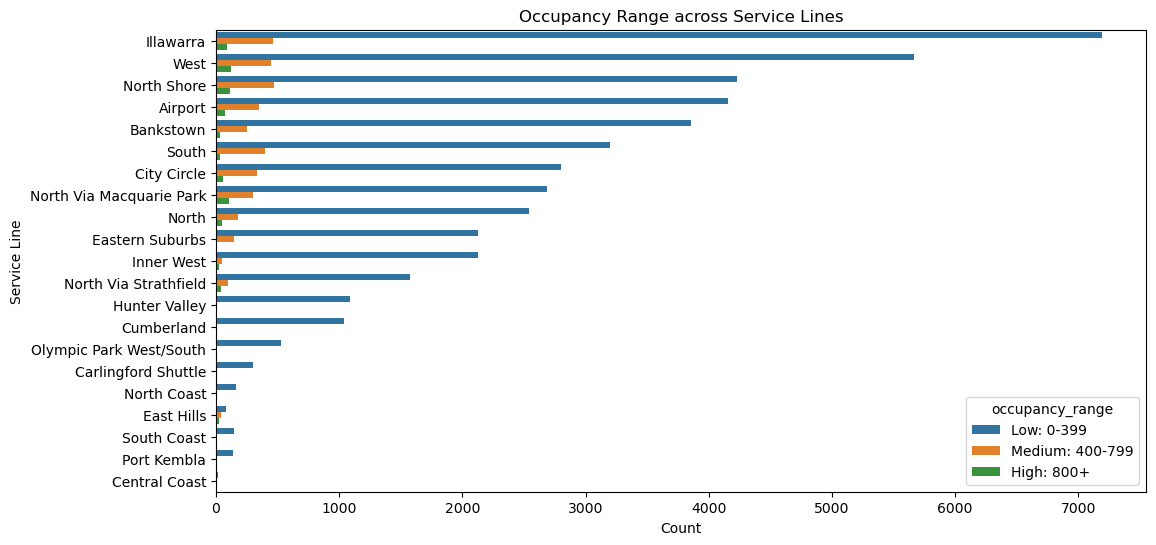

In [43]:
plt.figure(figsize=(12,6))
sns.countplot(y='service_line', hue='occupancy_range', data=df, order=df['service_line'].value_counts().index)
plt.title("Occupancy Range across Service Lines")
plt.xlabel("Count")
plt.ylabel("Service Line")
plt.show()

Insight: Service lines like West, North shore, Illawarra, North Via Macquarie Park & Airport may show more high-occupancy services than others

## Categorical Feature 2: direction & peak_period

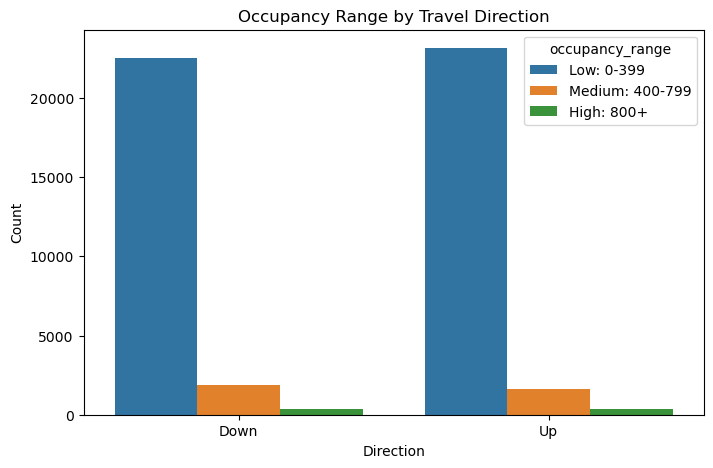

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x='direction', hue='occupancy_range', data=df)
plt.title("Occupancy Range by Travel Direction")
plt.xlabel("Direction")
plt.ylabel("Count")
plt.show()

Insight: Down One direction may be slightly more crowded due to work commute patterns

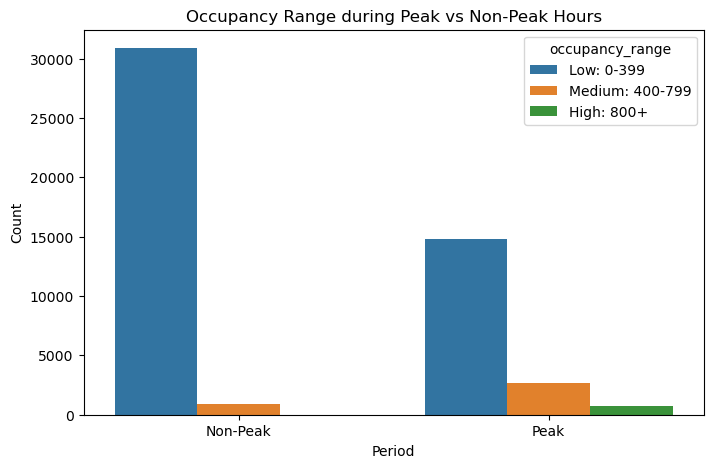

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='peak_period', hue='occupancy_range', data=df)
plt.title("Occupancy Range during Peak vs Non-Peak Hours")
plt.xlabel("Period")
plt.ylabel("Count")
plt.show()

Insight: Most trains have low occupancy in both periods, but peak hours have noticeably more medium and high occupancy compared to non-peak hours. This shows trains are generally more crowded during peak travel times.